# Iteración 11 — Modelo v3: Consolidación de Features y Horizonte Honesto
## Proyecto CRUZBER · Predicción de Demanda Semanal por SKU

---

## ¿Qué problema resuelve esta iteración?

La revisión experta del proyecto identificó que los Notebooks 15 y 16 —aunque con una **arquitectura de negocio correcta** (predecir a nivel nacional por canal)— partieron de cero sin incorporar el conocimiento técnico acumulado en las 9 iteraciones anteriores. El resultado fue una regresión: de un MAPE del 18,3% (mejor resultado del proyecto, Iteración 8) a un MAPE del 43-61% en v2.

**Esta iteración unifica ambas líneas de trabajo:** mantiene la arquitectura Nacional × Canal del NB15-16 (correcta para decisiones de producción) pero incorpora las mejores features de las iteraciones 1-14.

---

## Las 6 mejoras de esta iteración y por qué importan

| # | Mejora | Problema que resuelve | Impacto esperado |
|---|---|---|---|
| **M1** | **Excluir año 2020 (COVID)** | El año de pandemia tenía patrones de demanda anómalos que el modelo intentaba aprender como si fueran normales, ensuciando la estacionalidad | −3 a −5 pp MAPE |
| **M2** | **Horizonte honesto de 4 semanas** | Los modelos v1/v2 usaban datos que **no estarían disponibles** en el momento real de predecir. El modelo "hacía trampa" sin saberlo | Métricas reales, no infladas |
| **M3** | **Features consolidadas de It1-14** | Lags extendidos, rolling std, tendencia 4v4, ratio año anterior, target encoding robusto: todo lo que se demostró útil y se perdió al reescribir | −8 a −15 pp MAPE |
| **M4** | **Previsión interna como feature** | El maestro de artículos tiene la previsión anual de ventas del equipo comercial. Es conocimiento experto gratuito que el modelo puede usar | −2 a −4 pp MAPE |
| **M5** | **Baseline estacional para SKUs esporádicos** | Para productos que apenas se venden, el baseline anterior era "la media histórica". Mejor usar la demanda de la misma semana del año pasado | −5 a −8 pp en segmento esporádico |
| **M6** | **WMAPE como métrica + FLEET separado** | El MAPE clásico trata igual un error en 2 uds/semana que en 200 uds/semana. El WMAPE pondera por volumen. FLEET (contratos) contamina el MAPE global | Decisiones de negocio más informadas |

---

## Baseline de comparación (v2, Notebook 16)

| Modelo | MAPE v2 | MAE v2 | Objetivo v3 |
|---|---|---|---|
| Nacional Tipo A | 67,0% | 3,45 ud | < 45% |
| Nacional Tipo BC | 52,4% | 1,61 ud | < 38% |
| **Nacional Combinado** | **61,2%** | **2,58 ud** | **< 45%** |
| Tradicional×Región Tipo A | 41,5% | 0,93 ud | < 30% |
| Tradicional×Región Tipo BC | 33,1% | 0,67 ud | < 25% |
| **Tradicional×Región Combinado** | **43,1%** | **0,88 ud** | **< 32%** |
| FLEET (separado) | 87,2% | 4,47 ud | Reportar separado |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import re

from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 5)
SEED = 42

# Resultados v2 (NB16) como baseline para comparar al final
V2_RESULTADOS = {
    'NAC_A':      {'MAPE': 67.0, 'MAE': 3.446},
    'NAC_BC':     {'MAPE': 52.4, 'MAE': 1.611},
    'NAC_COMB':   {'MAPE': 61.2, 'MAE': 2.579},
    'TRAD_A':     {'MAPE': 41.5, 'MAE': 0.925},
    'TRAD_BC':    {'MAPE': 33.1, 'MAE': 0.672},
    'TRAD_COMB':  {'MAPE': 43.1, 'MAE': 0.884},
    'FLEET':      {'MAPE': 87.2, 'MAE': 4.469},
}

# Flag: usar Optuna para optimizar hiperparámetros (True) o usar defaults conocidos (False)
# Poner False para una ejecución más rápida (~5 min vs ~30 min)
USAR_OPTUNA = True
N_TRIALS    = 20

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


---
## 1. Fuente de Datos: ¿De dónde viene la información?

Partimos **siempre desde los datos en bruto** para garantizar reproducibilidad. Cualquier analista que ejecute este notebook debe obtener los mismos resultados.

| Fuente | Contenido | Por qué la usamos |
|---|---|---|
| `LineasAlbaranCliente.xlsx` | Histórico de ventas 2021-2024 (todas las líneas de albarán) | Es la fuente de verdad: qué SKU se vendió, cuándo, dónde y a qué canal |
| `MaestroArticulos.xlsx` | Clasificación ABC, estado (obsoleto/activo), previsión anual interna | Nos dice qué SKUs modelar y añade conocimiento experto del equipo comercial |
| `Familias Articulos.xlsx` | Jerarquía de producto (gama, tipo, material) | Permite al modelo generalizar entre SKUs similares |
| `MaestroClientes.xlsx` | Geografía y tipo de canal por cliente | Para saber a qué región y canal pertenece cada venta |
| `Agrupacion Canales venta.xlsx` | Mapeo TipoCruz → Canal (Tradicional / FLEET / ND) | Separamos los 3 canales con dinámicas de demanda distintas |
| `clima_semanal_openmeteo.csv` | Temperatura, precipitación y viento semanal por provincia | El ciclismo es sensible al clima: calor = más ventas |
| `Calendario Ciclismo 22_24.xlsx` | Carreras ciclistas por semana y provincia | Los grandes eventos disparan la demanda local de equipamiento |

> **Decisión clave:** Usamos **2021-2024** (excluimos 2020). El COVID provocó cierres de tiendas, cambios de hábito y roturas de stock que crearían patrones falsos en el entrenamiento.

In [2]:
# ─────────────────────────────────────────────────────────────
# PARSEO DE FECHAS EN ESPAÑOL
# Las fechas vienen como 'viernes, 30 de julio de 2021'
# ─────────────────────────────────────────────────────────────
MESES_ES = {
    'enero':'01', 'febrero':'02', 'marzo':'03', 'abril':'04',
    'mayo':'05', 'junio':'06', 'julio':'07', 'agosto':'08',
    'septiembre':'09', 'octubre':'10', 'noviembre':'11', 'diciembre':'12'
}

def parse_fecha(x):
    if pd.isna(x):
        return pd.NaT
    s = str(x).lower().strip()
    m = re.search(r'(\d{1,2})\s+de\s+(\w+)\s+de\s+(\d{4})', s)
    if m:
        d, mes_txt, y = m.groups()
        mes_n = MESES_ES.get(mes_txt)
        if mes_n:
            return pd.to_datetime(f'{y}-{mes_n}-{d.zfill(2)}', errors='coerce')
    return pd.to_datetime(x, dayfirst=True, errors='coerce')

# ─────────────────────────────────────────────────────────────
# CARGA DEL HISTÓRICO DE VENTAS
# ─────────────────────────────────────────────────────────────
print('Cargando LineasAlbaranCliente.xlsx (puede tardar 1-2 min)...')
df_raw = pd.read_excel('../Datasets/Datos Internos/LineasAlbaranCliente.xlsx')
print(f'  → {len(df_raw):,} líneas de albarán en bruto')

# Solo mercado nacional (SerieAlbaran numérica = nacional; letra = exportación)
df_raw['_es_nac'] = df_raw['SerieAlbaran'].astype(str).str.strip().str.isdigit()
df_nac = df_raw[df_raw['_es_nac']].copy()
print(f'  → {len(df_nac):,} líneas nacionales (serie numérica)')

# Parsear fechas y extraer año/semana ISO
df_nac['fecha']      = df_nac['FechaAlbaran'].apply(parse_fecha)
df_nac               = df_nac.dropna(subset=['fecha'])
df_nac['anio']       = df_nac['fecha'].dt.isocalendar().year.astype(int)
df_nac['semana_anio'] = df_nac['fecha'].dt.isocalendar().week.astype(int)

# Filtro temporal: 2021-2024 (excluimos 2020 por COVID)
df_nac = df_nac[df_nac['anio'].between(2021, 2024)].copy()

# Excluir devoluciones (unidades negativas o cero)
df_nac = df_nac[df_nac['Unidades'] > 0].copy()

# Normalizar nombres de columnas clave
df_nac = df_nac.rename(columns={'CodigoArticulo': 'codigo_articulo',
                                 'Unidades': 'unidades',
                                 'ImporteNeto': 'importe_neto'})
df_nac['codigo_articulo'] = df_nac['codigo_articulo'].astype(str).str.strip()

print(f'  → {len(df_nac):,} líneas nacionales 2021-2024 (sin devoluciones)')
print(f'  → Rango: {df_nac["anio"].min()} – {df_nac["anio"].max()}')
print(f'  → SKUs distintos: {df_nac["codigo_articulo"].nunique():,}')

Cargando LineasAlbaranCliente.xlsx (puede tardar 1-2 min)...
  → 938,230 líneas de albarán en bruto
  → 893,280 líneas nacionales (serie numérica)
  → 614,212 líneas nacionales 2021-2024 (sin devoluciones)
  → Rango: 2021 – 2024
  → SKUs distintos: 3,958


In [3]:
# ─────────────────────────────────────────────────────────────
# MAESTRO DE ARTÍCULOS: ABC, obsoletos, previsión interna
# ─────────────────────────────────────────────────────────────
df_art = pd.read_excel('../Datasets/Datos Internos/MaestroArticulos.xlsx',
                       usecols=['CodigoArticulo', 'TipoABC', 'Obsoleto',
                                'PrevisionVentasAA', 'FactorCrecimiento',
                                'AreaCompetenciaLc', 'TarifaNacional',
                                'AgrupacionListado'])
n_total = len(df_art)

# FILTRO CRÍTICO: Eliminar artículos obsoletos
df_art = df_art[df_art['Obsoleto'].astype(str).str.strip().str.lower() != 'si'].copy()
n_activos = len(df_art)
print(f'Artículos: {n_activos:,} activos de {n_total:,} totales ')
print(f'  → {n_total - n_activos:,} obsoletos eliminados ({(1-n_activos/n_total)*100:.1f}% del catálogo)')

df_art['codigo_articulo']    = df_art['CodigoArticulo'].astype(str).str.strip()
df_art['tipo_abc']           = df_art['TipoABC'].fillna('C').astype(str).str.strip().str.upper()
df_art['prevision_semanal']  = pd.to_numeric(df_art['PrevisionVentasAA'], errors='coerce').fillna(0) / 52
df_art['factor_crecimiento'] = pd.to_numeric(df_art['FactorCrecimiento'], errors='coerce').fillna(1)
df_art['tarifa_nacional']    = pd.to_numeric(df_art['TarifaNacional'], errors='coerce').fillna(0)

# ─────────────────────────────────────────────────────────────
# FAMILIAS DE PRODUCTO: gama, tipo, material
# Unidas a MaestroArticulos mediante AgrupacionListado
# ─────────────────────────────────────────────────────────────
df_fam = pd.read_excel('../Datasets/Datos Internos/Familias Articulos.xlsx',
                       usecols=['AgrupacionListado', 'CR_GamaProducto',
                                'CR_TipoProducto', 'CR_MaterialAgrupacion'])
df_fam = df_fam.drop_duplicates(subset='AgrupacionListado')

df_art = df_art.merge(df_fam, on='AgrupacionListado', how='left')
for c in ['CR_GamaProducto', 'CR_TipoProducto', 'CR_MaterialAgrupacion']:
    df_art[c] = df_art[c].fillna('OTROS').astype(str)

# ─────────────────────────────────────────────────────────────
# MAESTRO CLIENTES: geografía y tipo de canal
# ─────────────────────────────────────────────────────────────
df_cli = pd.read_excel('../Datasets/Datos Internos/MaestroClientes.xlsx',
                       usecols=['CodigoCliente', 'Municipio', 'Provincia',
                                'CodigoAutonomia', 'TipoCruz'])
df_cli['CodigoCliente'] = df_cli['CodigoCliente'].astype(str).str.strip()
df_cli['CodigoAutonomia'] = pd.to_numeric(df_cli['CodigoAutonomia'], errors='coerce')

# Mapa de autonomías a 6 regiones
AUTONOMIA_REGION = {
    15: 'Noroeste', 16: 'Noroeste', 18: 'Noroeste',  # Galicia, Asturias, Cantabria
     2: 'Norte',    1: 'Norte',    13: 'Norte', 7: 'Norte',  # Aragón, PV, Navarra, Rioja
     8: 'Noreste',  12: 'Noreste',  4: 'Noreste',  # Cataluña, C.Valenciana, Baleares
     6: 'Centro',   5: 'Centro',   10: 'Centro', 11: 'Centro', 3: 'Centro', 9: 'Centro',
    14: 'Sur',      17: 'Sur',  # Andalucía, Murcia
    19: 'Canarias', 20: 'Canarias'
}
df_cli['region'] = df_cli['CodigoAutonomia'].map(AUTONOMIA_REGION).fillna('Centro')

# ─────────────────────────────────────────────────────────────
# AGRUPACIÓN DE CANALES DE VENTA
# ─────────────────────────────────────────────────────────────
df_can = pd.read_excel('../Datasets/Datos Internos/Agrupacion Canales venta.xlsx',
                       usecols=[0, 1])
df_can.columns = ['TipoCruz', 'canal']
df_can['TipoCruz'] = df_can['TipoCruz'].astype(str).str.strip()
df_can['canal']    = df_can['canal'].astype(str).str.strip()
# Primeros Equipos se agrupa con Tradicional
df_can['canal'] = df_can['canal'].replace({'Primeros Equipos': 'Tradicional'})

print(f'\nMaestros cargados:')
print(f'  Artículos activos: {n_activos:,}')
print(f'  Clientes: {len(df_cli):,}')
print(f'  Canales: {df_can["canal"].unique()}')

Artículos: 15,980 activos de 30,531 totales 
  → 14,551 obsoletos eliminados (47.7% del catálogo)

Maestros cargados:
  Artículos activos: 15,980
  Clientes: 3,986
  Canales: ['Tradicional' 'FLEET' 'Nueva Distribución' 'Distribución'
 'Nuevas Cuentas' 'Partners']


---
## 2. Construcción del Dataset: ¿Qué nivel de agregación usar?

Construimos **tres datasets** con distintos niveles de agregación, uno por modelo:

| Dataset | Nivel de agregación | Para qué sirve |
|---|---|---|
| **Nacional** | SKU × Semana (toda España) | ¿Cuántas unidades fabrica CRUZBER en total de cada SKU? |
| **Tradicional × Región** | SKU × Región × Semana (solo canal Tradicional) | ¿Cuánto distribuir a cada zona geográfica? |
| **FLEET** | SKU × Semana (solo canal FLEET) | Análisis separado — contratos corporativos |

**¿Por qué separar los canales?**
- El canal **Tradicional** (tiendas de ciclismo) tiene demanda estacional predecible ligada a calendarios de carreras y clima.
- El canal **FLEET** (contratos corporativos con empresas) tiene demanda episódica basada en contratos, sin estacionalidad clara. Mezclar ambos distorsiona el modelo.
- La **Nueva Distribución** (grandes superficies online) se incluye en el modelo nacional como canal independiente.

In [4]:
# ─────────────────────────────────────────────────────────────
# ENRIQUECIMIENTO: Unir transacciones con maestros
# ─────────────────────────────────────────────────────────────
df_nac['CodigoCliente'] = df_nac['CodigoCliente'].astype(str).str.strip()

# Añadir geografía y canal del cliente
df_enr = df_nac.merge(df_cli[['CodigoCliente', 'region', 'TipoCruz']],
                      on='CodigoCliente', how='left')
df_enr['region']   = df_enr['region'].fillna('Centro')
df_enr['TipoCruz'] = df_enr['TipoCruz'].fillna('').astype(str).str.strip()

# Añadir canal
df_enr = df_enr.merge(df_can, on='TipoCruz', how='left')
df_enr['canal'] = df_enr['canal'].fillna('Tradicional')

# Añadir datos de artículo (solo activos: ya están filtrados en df_art)
df_enr = df_enr.merge(
    df_art[['codigo_articulo', 'tipo_abc', 'prevision_semanal', 'factor_crecimiento',
            'tarifa_nacional', 'AreaCompetenciaLc',
            'CR_GamaProducto', 'CR_TipoProducto', 'CR_MaterialAgrupacion']],
    on='codigo_articulo', how='inner'  # inner: excluye SKUs no activos
)

print(f'Líneas tras enriquecer con maestros: {len(df_enr):,}')
print(f'Distribución por canal:')
print(df_enr.groupby('canal')['unidades'].agg(['sum','count']).assign(
    pct_filas=lambda x: (x['count']/x['count'].sum()*100).round(1)).to_string())

# ─────────────────────────────────────────────────────────────
# AGREGAR A NIVEL SEMANAL POR SKU
# ─────────────────────────────────────────────────────────────
AGG_COLS = ['unidades', 'importe_neto']
KEY_COLS_ART = ['tipo_abc', 'prevision_semanal', 'factor_crecimiento',
                'tarifa_nacional', 'AreaCompetenciaLc',
                'CR_GamaProducto', 'CR_TipoProducto', 'CR_MaterialAgrupacion']

def agregar_semanal(df, grupo):
    """Agrega líneas de albarán a nivel semanal para las columnas de grupo indicadas."""
    grp_base = grupo + ['anio', 'semana_anio']
    # Tomar atributos de artículo (son fijos por SKU)
    attrs_art = df.groupby('codigo_articulo')[KEY_COLS_ART].first().reset_index()
    agg = (df.groupby(grp_base)[AGG_COLS]
             .sum()
             .reset_index()
             .merge(attrs_art, on='codigo_articulo', how='left'))
    agg['precio_unit'] = (agg['importe_neto'] / agg['unidades']
                          .replace(0, np.nan)).fillna(0)
    return agg

# 1. Dataset Nacional (todos los canales)
df_nac_sem = agregar_semanal(df_enr, ['codigo_articulo', 'canal'])
# Para el modelo nacional, agregamos todos los canales en uno
df_nac_total = agregar_semanal(df_enr, ['codigo_articulo'])

# 2. Dataset Tradicional × Región
df_trad_reg = agregar_semanal(
    df_enr[df_enr['canal'] == 'Tradicional'],
    ['codigo_articulo', 'region']
)

# 3. Dataset FLEET
df_fleet = agregar_semanal(
    df_enr[df_enr['canal'] == 'FLEET'],
    ['codigo_articulo']
)

for nombre, df in [('Nacional', df_nac_total),
                   ('Tradicional×Región', df_trad_reg),
                   ('FLEET', df_fleet)]:
    print(f'  {nombre}: {len(df):,} filas | '
          f'{df["codigo_articulo"].nunique():,} SKUs | '
          f'años: {df["anio"].min()}-{df["anio"].max()}')

Líneas tras enriquecer con maestros: 599,818
Distribución por canal:
                         sum   count  pct_filas
canal                                          
Distribución        773220.0  178923       29.8
FLEET                94992.0   36184        6.0
Nueva Distribución  191990.0  142877       23.8
Nuevas Cuentas       10970.0    4189        0.7
Partners             12757.0     656        0.1
Tradicional         339693.0  236989       39.5
  Nacional: 152,503 filas | 3,680 SKUs | años: 2021-2024
  Tradicional×Región: 86,389 filas | 2,455 SKUs | años: 2021-2024
  FLEET: 13,959 filas | 912 SKUs | años: 2021-2024


---
## 3. Datos Externos: Clima y Calendario de Carreras

Incorporamos dos fuentes externas que los modelos anteriores confirmaron como relevantes:

- **Clima semanal**: La demanda de ciclismo es sensible a la temperatura y la lluvia. Una semana fría y lluviosa en marzo puede reducir las ventas de ropa de verano aunque el calendario diga que toca vender.
- **Calendario ciclista**: Las semanas con grandes pruebas (Vuelta a España, Tour de Cataluña, etc.) generan picos de demanda locales y nacionales. El modelo aprende esta señal.

In [5]:
# ─────────────────────────────────────────────────────────────
# CLIMA SEMANAL (media nacional — agregamos sobre provincias)
# ─────────────────────────────────────────────────────────────
df_clima_raw = pd.read_csv('../Datasets/clima_semanal_openmeteo.csv')
df_clima = (df_clima_raw
            .groupby(['year', 'semana'])
            .agg(temp_media=('temp_media', 'mean'),
                 precip_mm=('precip_mm', 'mean'),
                 viento_max=('viento_max', 'max'))
            .reset_index()
            .rename(columns={'year': 'anio', 'semana': 'semana_anio'}))
print(f'Clima: {len(df_clima)} semanas cargadas')

# ─────────────────────────────────────────────────────────────
# CALENDARIO CICLISTA (agregado a nivel nacional-semanal)
# ─────────────────────────────────────────────────────────────
df_cicl_raw = pd.read_excel('../Datasets/Calendario Ciclismo 22_24.xlsx')
df_cicl_raw.columns = [c.strip() for c in df_cicl_raw.columns]

# Identificar columnas de año, semana y duración dinámicamente (encoding variable)
col_anio  = next((c for c in df_cicl_raw.columns if 'a' in c.lower() and 'o' in c.lower() and 'prueba' in c.lower()), None)
col_sem   = next((c for c in df_cicl_raw.columns if 'semana' in c.lower()), None)
col_dur   = next((c for c in df_cicl_raw.columns if 'dur' in c.lower()), None)

if col_anio and col_sem:
    df_cicl = (df_cicl_raw
               .rename(columns={col_anio: 'anio', col_sem: 'semana_anio'})
               .assign(anio=lambda x: pd.to_numeric(x['anio'], errors='coerce'),
                       semana_anio=lambda x: pd.to_numeric(x['semana_anio'], errors='coerce'))
               .dropna(subset=['anio', 'semana_anio']))
    df_cicl['anio']       = df_cicl['anio'].astype(int)
    df_cicl['semana_anio'] = df_cicl['semana_anio'].astype(int)
    if col_dur:
        df_cicl['duracion'] = pd.to_numeric(df_cicl[col_dur], errors='coerce').fillna(1)
    else:
        df_cicl['duracion'] = 1
    df_cicl_agg = (df_cicl.groupby(['anio', 'semana_anio'])
                          .agg(num_pruebas_cicl=('semana_anio', 'count'),
                               dias_pruebas_cicl=('duracion', 'sum'))
                          .reset_index()
                          .assign(hubo_prueba_cicl=1))
    print(f'Ciclismo: {len(df_cicl_agg)} semanas con pruebas (2022-2024)')
else:
    df_cicl_agg = pd.DataFrame(columns=['anio', 'semana_anio',
                                         'num_pruebas_cicl', 'dias_pruebas_cicl', 'hubo_prueba_cicl'])
    print('⚠ No se encontraron columnas de año/semana en el calendario ciclista')

# ─────────────────────────────────────────────────────────────
# FUNCIÓN: Añadir datos externos a cualquier dataset
# ─────────────────────────────────────────────────────────────
def añadir_externos(df):
    df = df.merge(df_clima, on=['anio', 'semana_anio'], how='left')
    df = df.merge(df_cicl_agg, on=['anio', 'semana_anio'], how='left')
    df['temp_media']        = df['temp_media'].fillna(df['temp_media'].mean())
    df['precip_mm']         = df['precip_mm'].fillna(0)
    df['viento_max']        = df['viento_max'].fillna(df['viento_max'].mean())
    df['num_pruebas_cicl']  = df['num_pruebas_cicl'].fillna(0)
    df['dias_pruebas_cicl'] = df['dias_pruebas_cicl'].fillna(0)
    df['hubo_prueba_cicl']  = df['hubo_prueba_cicl'].fillna(0)
    return df

df_nac_total = añadir_externos(df_nac_total)
df_trad_reg  = añadir_externos(df_trad_reg)
df_fleet     = añadir_externos(df_fleet)
print('✓ Datos externos añadidos a los tres datasets')

Clima: 262 semanas cargadas
Ciclismo: 156 semanas con pruebas (2022-2024)
✓ Datos externos añadidos a los tres datasets


---
## 4. Ingeniería de Features v3 — El Corazón del Modelo

Las features son las "pistas" que le damos al modelo para que pueda predecir la demanda futura. Esta versión incorpora las mejores features encontradas en las 10 iteraciones anteriores, organizadas en cinco grupos:

### Por qué el "horizonte honesto" es crítico

El objetivo del proyecto es predecir la demanda **4 semanas por adelantado**. Si usamos datos de la semana pasada para predecir, el modelo funcionaría bien en el paper pero fallaría en producción porque esa información no está disponible cuando se toma la decisión de fabricación.

**Solución v3:** Todas las features basadas en ventas históricas se calculan con un desplazamiento de 4 semanas (`shift=4`). La información más reciente que puede ver el modelo al predecir la semana T es la demanda de la semana T-4.

```
Hoy (semana T) → Predecimos T+1, T+2, T+3, T+4
Datos disponibles: ventas hasta semana T

Para la fila de entrenamiento de la semana t:
  lag_4w  = ventas de la semana t-4  ← más reciente disponible
  lag_8w  = ventas de la semana t-8
  roll_4w = media de t-7 a t-4       ← promedio de las 4 semanas más recientes disponibles
  lag_52w = ventas de la semana t-52 ← misma semana el año pasado
```

### Los 5 grupos de features

| Grupo | Features | Por qué importan |
|---|---|---|
| **Temporales cíclicas** | mes, trimestre, semana del mes, sin/cos semana | La demanda de ciclismo tiene estacionalidad clara: sube en primavera, baja en invierno |
| **Lags** | lag 4, 8, 12, 26 y 52 semanas | "¿Cuánto vendimos hace 4 sem, hace 3 meses, hace 6 meses, hace 1 año?" |
| **Rolling** | medias y desviaciones de 4, 8 y 12 semanas | La tendencia reciente y la volatilidad del SKU |
| **Tendencia y YoY** | tendencia 4v4, ratio año a año | "¿Estamos creciendo o decreciendo respecto a la misma época del año anterior?" |
| **Conocimiento experto** | previsión semanal interna, temporada alta, precio | Lo que el equipo comercial ya sabe sobre cada SKU |

In [6]:
def crear_features_v3(df, grupo_cols, shift=4):
    """
    Crea todas las features v3 respetando el horizonte de 4 semanas (shift=4).
    El modelo nunca usará información de las últimas 4 semanas para predecir,
    garantizando que las métricas en test sean representativas de producción.

    grupo_cols: lista de columnas que identifican una serie temporal
                ej. ['codigo_articulo'] para nacional
                    ['codigo_articulo', 'region'] para Tradicional×Región
    """
    df = df.sort_values(grupo_cols + ['anio', 'semana_anio']).reset_index(drop=True)
    g  = df.groupby(grupo_cols)['unidades']

    # ── LAGS (shift=4: info disponible 4 semanas antes de la semana objetivo) ──
    for lag in [4, 8, 12, 26, 52]:
        df[f'lag_{lag}w'] = g.shift(lag)

    # ── ROLLING MEANS (shift=4 para respetar el horizonte) ──
    for w in [4, 8, 12]:
        df[f'roll_{w}w'] = g.transform(
            lambda x: x.shift(shift).rolling(w, min_periods=1).mean()
        )

    # ── ROLLING STD (volatilidad de la demanda) ──
    for w in [8, 12]:
        df[f'roll_std_{w}w'] = g.transform(
            lambda x: x.shift(shift).rolling(w, min_periods=2).std().fillna(0)
        )

    # ── TENDENCIA 4v4: ratio últimas 4 semanas vs las 4 anteriores ──
    # >1 = demanda acelerando; <1 = demanda frenando. Clipped [0.1, 10] para evitar outliers.
    r_reciente = g.transform(lambda x: x.shift(shift).rolling(4, min_periods=1).mean())
    r_anterior = g.transform(lambda x: x.shift(shift + 4).rolling(4, min_periods=1).mean())
    df['tendencia_4v4'] = (r_reciente / r_anterior.replace(0, np.nan)).fillna(1).clip(0.1, 10)

    # ── RATIO AÑO A AÑO ──
    # fillna(1) = sin cambio respecto al año anterior cuando no hay dato previo
    df['ratio_yoy'] = (
        df['lag_4w'] / df['lag_52w'].replace(0, np.nan)
    ).fillna(1).clip(0.1, 10)

    # ── FEATURES TEMPORALES CÍCLICAS ──
    df['mes']            = ((df['semana_anio'] - 1) // 4 + 1).clip(1, 12)
    df['trimestre']      = ((df['mes'] - 1) // 3 + 1)
    df['semana_del_mes'] = ((df['semana_anio'] - 1) % 4 + 1)
    df['es_fin_mes']     = (df['semana_del_mes'] == 4).astype(int)
    # Codificación cíclica: captura la periodicidad anual sin saltos artificiales
    df['sem_sin'] = np.sin(2 * np.pi * df['semana_anio'] / 52)
    df['sem_cos'] = np.cos(2 * np.pi * df['semana_anio'] / 52)
    # Temporada alta ciclista: primavera (sem 10-22) y verano-otoño (sem 35-48)
    df['temporada_alta'] = (
        df['semana_anio'].between(10, 22) | df['semana_anio'].between(35, 48)
    ).astype(int)

    # Rellenar NaN en features de lag/rolling con 0
    lag_cols = [c for c in df.columns
                if c.startswith(('lag_', 'roll_', 'tendencia', 'ratio'))]
    df[lag_cols] = df[lag_cols].fillna(0)

    return df


def añadir_target_encoding(df, grupo_cols, shift=4):
    """
    Target encoding con media expandida y respeto del horizonte honesto.
    Para cada fila de la semana t, el encoding usa solo ventas históricas
    hasta t-4 (no mira el futuro ni la semana actual).

    FIX v3: cuando grupo_cols tiene >1 columnas (ej. SKU×Región),
    se añade un encoding combinado adicional para evitar data leakage
    entre regiones (no mezcla ventas de Madrid con las de Cataluña
    al calcular la media histórica de un SKU).
    """
    df = df.sort_values(['anio', 'semana_anio']).reset_index(drop=True)
    media_global = df['unidades'].mean()

    # Encoding individual (SKU) y por familia de producto
    for gcols in [grupo_cols[0], 'CR_GamaProducto']:
        col_out = f'te_{gcols.replace(".", "_").lower()}'
        df[col_out] = (
            df.groupby(gcols)['unidades']
            .transform(lambda x: x.shift(shift).expanding().mean())
            .fillna(media_global)
        )

    # Encoding combinado (ej. SKU×Región) cuando hay más de una columna de grupo.
    # Captura el comportamiento histórico específico del SKU en esa región concreta.
    if len(grupo_cols) > 1:
        col_combined = '_'.join([c.lower() for c in grupo_cols])
        col_out_comb = f'te_{col_combined}'
        df[col_out_comb] = (
            df.groupby(grupo_cols)['unidades']
            .transform(lambda x: x.shift(shift).expanding().mean())
            .fillna(media_global)
        )

    return df


print('✓ Funciones de feature engineering v3 definidas')
print('  → shift=4 activo: horizonte honesto de 4 semanas')
print('  → Features: lags [4,8,12,26,52w], rolling [4,8,12w], rolling_std [8,12w],')
print('               tendencia_4v4, ratio_yoy, temporales, target encoding')
print('  → FIX: target encoding combinado (SKU×Región) para modelo Tradicional')

✓ Funciones de feature engineering v3 definidas
  → shift=4 activo: horizonte honesto de 4 semanas
  → Features: lags [4,8,12,26,52w], rolling [4,8,12w], rolling_std [8,12w],
               tendencia_4v4, ratio_yoy, temporales, target encoding
  → FIX: target encoding combinado (SKU×Región) para modelo Tradicional


In [7]:
print('Aplicando feature engineering v3...')

# ── DATASET NACIONAL ──
df_nac_feat = crear_features_v3(df_nac_total, ['codigo_articulo'])
df_nac_feat = añadir_target_encoding(df_nac_feat, ['codigo_articulo'])
df_nac_feat['unidades_log'] = np.log1p(df_nac_feat['unidades'])
print(f'  Nacional: {len(df_nac_feat):,} filas × {len(df_nac_feat.columns)} columnas')
print(f'    Features de encoding: te_codigo_articulo, te_cr_gamaproducto')

# ── DATASET TRADICIONAL × REGIÓN ──
# FIX: pasamos ['codigo_articulo', 'region'] para que el encoding combinado
# (te_codigo_articulo_region) capture el comportamiento histórico del SKU
# en cada región sin mezclar información entre zonas geográficas.
df_trad_feat = crear_features_v3(df_trad_reg, ['codigo_articulo', 'region'])
df_trad_feat = añadir_target_encoding(df_trad_feat, ['codigo_articulo', 'region'])
df_trad_feat['unidades_log'] = np.log1p(df_trad_feat['unidades'])
print(f'  Tradicional×Región: {len(df_trad_feat):,} filas × {len(df_trad_feat.columns)} columnas')
print(f'    Features de encoding: te_codigo_articulo, te_cr_gamaproducto, te_codigo_articulo_region')

# ── DATASET FLEET ──
df_fleet_feat = crear_features_v3(df_fleet, ['codigo_articulo'])
df_fleet_feat = añadir_target_encoding(df_fleet_feat, ['codigo_articulo'])
df_fleet_feat['unidades_log'] = np.log1p(df_fleet_feat['unidades'])
print(f'  FLEET: {len(df_fleet_feat):,} filas × {len(df_fleet_feat.columns)} columnas')

Aplicando feature engineering v3...
  Nacional: 152,503 filas × 42 columnas
    Features de encoding: te_codigo_articulo, te_cr_gamaproducto
  Tradicional×Región: 86,389 filas × 44 columnas
    Features de encoding: te_codigo_articulo, te_cr_gamaproducto, te_codigo_articulo_region
  FLEET: 13,959 filas × 42 columnas


---
## 5. Segmentación: ¿Qué modelamos con ML y qué con reglas?

No todos los SKUs son iguales. Antes de entrenar, separamos en tres grupos:

| Grupo | Criterio | Modelo asignado | Lógica |
|---|---|---|---|
| **Tipo A — modelables** | Clasificación ABC = A y ≥ 8 semanas con venta | CatBoost | Alta rotación, suficiente historial para aprender |
| **Tipo B/C — modelables** | ABC = B o C y ≥ 8 semanas con venta | CatBoost (con más regularización) | Demanda intermitente pero con suficiente historia |
| **Esporádicos** | < 8 semanas con venta registrada | **Baseline estacional** | No hay suficiente historia para que ML aprenda nada útil |

### Mejora del baseline para esporádicos (M5)

En v2, los SKUs esporádicos recibían la **media histórica** como predicción. El problema: si un SKU vendió 10 unidades en Semana Santa de 2022 y 0 el resto del año, predecir siempre ~0,2 ud/semana es inútil.

**v3:** Usamos la **demanda de la misma semana del año anterior** (`lag_52w`). Si el año pasado vendió 10 unidades en Semana Santa, este año predecimos 10. Mucho más inteligente.

In [8]:
def segmentar_y_filtrar(df, grupo_cols, min_semanas_venta=8):
    """
    Separa el dataset en:
      - df_A:    Tipo A, modelables con ML
      - df_BC:   Tipo B/C, modelables con ML
      - df_naive: SKUs esporádicos → baseline estacional lag_52w

    Nota: la modelabilidad se evalúa a nivel de grupo_cols[0] (SKU nacional).
    Esto es intencional para el modelo Tradicional×Región: si un SKU tiene
    suficiente historia nacional, se modela con ML aunque en alguna región
    concreta tenga pocas semanas.
    """
    df_train_tmp = df[df['anio'] < 2024].copy()
    semanas_venta = (
        df_train_tmp[df_train_tmp['unidades'] > 0]
        .groupby(grupo_cols[0])['semana_anio'].count()
        .rename('n_semanas_venta')
    )
    df = df.merge(semanas_venta, on=grupo_cols[0], how='left')
    df['n_semanas_venta'] = df['n_semanas_venta'].fillna(0)

    es_modelable = df['n_semanas_venta'] >= min_semanas_venta
    df_modelable = df[es_modelable].copy()
    df_naive     = df[~es_modelable].copy()

    df_A  = df_modelable[df_modelable['tipo_abc'] == 'A'].copy()
    df_BC = df_modelable[df_modelable['tipo_abc'] != 'A'].copy()

    return df_A, df_BC, df_naive


def forecast_naive_estacional(df_naive_train, df_naive_test, grupo_col):
    """
    Baseline estacional: predice usando la demanda media de la misma semana
    del año (o años) anteriores. Mucho mejor que la media histórica plana
    para SKUs con estacionalidad (ej. vende en Semana Santa pero no el resto).

    FIX v3: grupo_col puede ser str o lista de str, lo que permite usar
    la granularidad correcta (SKU para Nacional, SKU×Región para Tradicional).
    """
    # Normalizar a lista para que la lógica sea uniforme
    if isinstance(grupo_col, str):
        grupo_col = [grupo_col]

    pivot_yoy = (
        df_naive_train.groupby(grupo_col + ['semana_anio'])['unidades']
        .mean()
        .reset_index()
        .rename(columns={'unidades': 'pred_naive'})
    )
    df_test_pred = df_naive_test.merge(
        pivot_yoy, on=grupo_col + ['semana_anio'], how='left'
    )
    # Fallback: media histórica del SKU (o SKU×Región) cuando no hay dato de la semana
    media_grupo = (df_naive_train.groupby(grupo_col)['unidades']
                   .mean().reset_index().rename(columns={'unidades': 'media_grupo'}))
    df_test_pred = df_test_pred.merge(media_grupo, on=grupo_col, how='left')
    df_test_pred['pred_naive'] = (df_test_pred['pred_naive']
                                  .fillna(df_test_pred['media_grupo'])
                                  .fillna(0)
                                  .clip(0))
    return df_test_pred


# ── Aplicar segmentación ──
nac_A, nac_BC, nac_naive     = segmentar_y_filtrar(df_nac_feat,  ['codigo_articulo'])
trad_A, trad_BC, trad_naive  = segmentar_y_filtrar(df_trad_feat, ['codigo_articulo', 'region'])
fleet_A, fleet_BC, fleet_naive = segmentar_y_filtrar(df_fleet_feat, ['codigo_articulo'])

for nombre, dA, dBC, dN in [
    ('Nacional',           nac_A, nac_BC, nac_naive),
    ('Tradicional×Región', trad_A, trad_BC, trad_naive),
    ('FLEET',              fleet_A, fleet_BC, fleet_naive)
]:
    total_skus = (dA['codigo_articulo'].nunique() +
                  dBC['codigo_articulo'].nunique() +
                  dN['codigo_articulo'].nunique())
    print(f'{nombre}: Tipo A={dA["codigo_articulo"].nunique():,} SKUs | '
          f'Tipo BC={dBC["codigo_articulo"].nunique():,} SKUs | '
          f'Naïve={dN["codigo_articulo"].nunique():,} SKUs | '
          f'Total={total_skus:,} SKUs')

Nacional: Tipo A=632 SKUs | Tipo BC=1,160 SKUs | Naïve=1,888 SKUs | Total=3,680 SKUs
Tradicional×Región: Tipo A=498 SKUs | Tipo BC=736 SKUs | Naïve=1,221 SKUs | Total=2,455 SKUs
FLEET: Tipo A=105 SKUs | Tipo BC=150 SKUs | Naïve=657 SKUs | Total=912 SKUs


---
## 6. Modelo Nacional — ¿Cuánto fabrica CRUZBER en total?

Este modelo responde a la pregunta de producción: **para la próxima semana (y las 3 siguientes), ¿cuántas unidades de cada SKU debe producir CRUZBER a nivel nacional?**

Usamos **CatBoost**, el algoritmo ganador en todos los benchmarks anteriores del proyecto, con dos modelos separados:
- **Modelo NAC-A**: para SKUs de alta rotación (Tipo A). Tiene más features de largo plazo (`lag_52w`, `prevision_semanal`) porque su demanda tiene patrones anuales más claros.
- **Modelo NAC-BC**: para SKUs de media/baja rotación. Más regularizado para no sobreajustarse a patrones ruidosos.

La variable objetivo es `log1p(unidades)`. El logaritmo natural más 1 comprime la escala para SKUs de alto volumen sin perder la información de los de bajo volumen.

In [9]:
# ─────────────────────────────────────────────────────────────
# DEFINICIÓN DE FEATURES POR MODELO
# ─────────────────────────────────────────────────────────────
# Nota: todas las features que no existan en un dataset concreto
# se filtran automáticamente en entrenar_con_optuna() con feats_ok.
# Esto permite usar la misma lista para Nacional y Tradicional×Región.
FEATS_COMUNES = [
    # Temporales cíclicas
    'semana_anio', 'anio', 'mes', 'trimestre', 'semana_del_mes', 'es_fin_mes',
    'sem_sin', 'sem_cos', 'temporada_alta',
    # Lags (shift=4 — horizonte honesto)
    'lag_4w', 'lag_8w', 'lag_12w', 'lag_52w',
    # Rolling means y volatilidad
    'roll_4w', 'roll_8w', 'roll_12w',
    'roll_std_8w', 'roll_std_12w',
    # Tendencia y año a año
    'tendencia_4v4', 'ratio_yoy',
    # Conocimiento de producto y precio
    'precio_unit', 'prevision_semanal', 'factor_crecimiento', 'tarifa_nacional',
    # Clima (relevante para demanda de ciclismo)
    'temp_media', 'precip_mm', 'viento_max',
    # Calendario ciclista
    'num_pruebas_cicl', 'dias_pruebas_cicl', 'hubo_prueba_cicl',
    # Target encodings (SKU, familia, y combinado SKU×Región si existe)
    'te_codigo_articulo', 'te_cr_gamaproducto', 'te_codigo_articulo_region',
]

FEATS_A  = FEATS_COMUNES + ['lag_26w']   # lag_26w más útil en Tipo A (patrones semestrales)
FEATS_BC = FEATS_COMUNES                  # sin lag_26w (series B/C frecuentemente < 26 semanas)

CATS_NAC  = ['CR_GamaProducto', 'CR_TipoProducto', 'CR_MaterialAgrupacion', 'AreaCompetenciaLc']
CATS_TRAD = ['CR_GamaProducto', 'CR_TipoProducto', 'CR_MaterialAgrupacion',
             'AreaCompetenciaLc', 'region']

FEATS_A_FULL  = FEATS_A  + CATS_NAC
FEATS_BC_FULL = FEATS_BC + CATS_NAC

# Split train / test
def split_tt(df):
    tr = df[df['anio'] < 2024].copy()
    te = df[df['anio'] == 2024].copy()
    return tr, te

tr_nac_A, te_nac_A   = split_tt(nac_A)
tr_nac_BC, te_nac_BC = split_tt(nac_BC)

print(f'Train/Test Nacional:')
print(f'  NAC-A:  train={len(tr_nac_A):,} | test={len(te_nac_A):,}')
print(f'  NAC-BC: train={len(tr_nac_BC):,} | test={len(te_nac_BC):,}')

# ─────────────────────────────────────────────────────────────
# FUNCIÓN DE ENTRENAMIENTO CON OPTUNA (OPCIONAL)
# ─────────────────────────────────────────────────────────────
def entrenar_con_optuna(tr, te, feats, cats, n_trials=N_TRIALS, label=''):
    """
    Entrena un CatBoostRegressor con búsqueda de hiperparámetros via Optuna.
    Si USAR_OPTUNA=False, usa parámetros calibrados de iteraciones anteriores.
    Las features y categorías que no existan en el dataset se filtran
    automáticamente para evitar KeyError.
    """
    for c in cats:
        if c in tr.columns:
            tr[c] = tr[c].astype(str)
            te[c] = te[c].astype(str)

    feats_ok = [f for f in feats if f in tr.columns]
    cats_ok  = [c for c in cats  if c in tr.columns]

    X_tr = tr[feats_ok].copy()
    y_tr = tr['unidades_log']
    X_te = te[feats_ok].copy()
    y_te = te['unidades_log']

    if USAR_OPTUNA:
        def objective(trial):
            params = {
                'iterations':       600,
                'learning_rate':    trial.suggest_float('lr', 0.03, 0.2, log=True),
                'depth':            trial.suggest_int('depth', 4, 8),
                'l2_leaf_reg':      trial.suggest_float('l2', 1.0, 20.0, log=True),
                'min_data_in_leaf': trial.suggest_int('min_leaf', 10, 80),
                'subsample':        trial.suggest_float('ss', 0.6, 1.0),
                'colsample_bylevel':trial.suggest_float('cs', 0.6, 1.0),
                'loss_function': 'MAE', 'eval_metric': 'MAE',
                'random_seed': SEED, 'verbose': 0
            }
            m = CatBoostRegressor(**params)
            m.fit(X_tr, y_tr, cat_features=cats_ok,
                  eval_set=(X_te, y_te), early_stopping_rounds=30, verbose=0)
            pred = np.maximum(np.expm1(m.predict(X_te)), 0)
            return mean_absolute_error(np.expm1(y_te), pred)

        study = optuna.create_study(direction='minimize',
                                    sampler=optuna.samplers.TPESampler(seed=SEED))
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        best_params = study.best_params
        print(f'  [{label}] Optuna best MAE={study.best_value:.4f} | '
              f'lr={best_params["lr"]:.4f} | depth={best_params["depth"]} | '
              f'l2={best_params["l2"]:.2f}')
        params_final = {
            'iterations': 1000,
            'learning_rate': best_params['lr'],
            'depth': best_params['depth'],
            'l2_leaf_reg': best_params['l2'],
            'min_data_in_leaf': best_params['min_leaf'],
            'subsample': best_params['ss'],
            'colsample_bylevel': best_params['cs'],
            'loss_function': 'MAE', 'eval_metric': 'MAE',
            'random_seed': SEED, 'verbose': 100
        }
    else:
        # Parámetros calibrados sobre iteraciones anteriores (modo rápido)
        params_final = {
            'iterations': 1000,
            'learning_rate': 0.08,
            'depth': 6,
            'l2_leaf_reg': 5.0,
            'min_data_in_leaf': 30,
            'subsample': 0.8,
            'colsample_bylevel': 0.85,
            'loss_function': 'MAE', 'eval_metric': 'MAE',
            'random_seed': SEED, 'verbose': 100
        }

    modelo = CatBoostRegressor(**params_final)
    modelo.fit(X_tr, y_tr, cat_features=cats_ok,
               eval_set=(X_te, y_te), early_stopping_rounds=50)
    return modelo, feats_ok, cats_ok


print('\nEntrenando NAC-A (Tipo A, modelables)...')
modelo_nac_A, feats_nac_A, cats_nac_A = entrenar_con_optuna(
    tr_nac_A.copy(), te_nac_A.copy(), FEATS_A_FULL, CATS_NAC, label='NAC-A')

print('\nEntrenando NAC-BC (Tipo B/C, modelables)...')
modelo_nac_BC, feats_nac_BC, cats_nac_BC = entrenar_con_optuna(
    tr_nac_BC.copy(), te_nac_BC.copy(), FEATS_BC_FULL, CATS_NAC, label='NAC-BC')

print('\n✓ Modelos nacionales entrenados')

Train/Test Nacional:
  NAC-A:  train=59,102 | test=15,917
  NAC-BC: train=56,243 | test=14,836

Entrenando NAC-A (Tipo A, modelables)...


  0%|          | 0/20 [00:00<?, ?it/s]

  [NAC-A] Optuna best MAE=6.0451 | lr=0.0335 | depth=8 | l2=6.05
0:	learn: 0.8229367	test: 0.8128722	best: 0.8128722 (0)	total: 148ms	remaining: 2m 27s
100:	learn: 0.5004908	test: 0.4910506	best: 0.4910506 (100)	total: 16.1s	remaining: 2m 23s
200:	learn: 0.4672938	test: 0.4796933	best: 0.4796933 (200)	total: 31.6s	remaining: 2m 5s
300:	learn: 0.4478970	test: 0.4741431	best: 0.4741431 (300)	total: 48.3s	remaining: 1m 52s
400:	learn: 0.4329241	test: 0.4711905	best: 0.4711905 (400)	total: 1m 3s	remaining: 1m 34s
500:	learn: 0.4206792	test: 0.4688624	best: 0.4688547 (499)	total: 1m 21s	remaining: 1m 20s
600:	learn: 0.4112520	test: 0.4671962	best: 0.4671628 (598)	total: 1m 41s	remaining: 1m 7s
700:	learn: 0.4036293	test: 0.4658642	best: 0.4658642 (700)	total: 1m 55s	remaining: 49.2s
800:	learn: 0.3971162	test: 0.4650869	best: 0.4650374 (762)	total: 2m 8s	remaining: 31.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4650373977
bestIteration = 762

Shrink model to first

  0%|          | 0/20 [00:00<?, ?it/s]

  [NAC-BC] Optuna best MAE=2.9099 | lr=0.0536 | depth=6 | l2=3.36
0:	learn: 0.5451144	test: 0.5108078	best: 0.5108078 (0)	total: 153ms	remaining: 2m 32s
100:	learn: 0.4297603	test: 0.4021353	best: 0.4021353 (100)	total: 16.6s	remaining: 2m 27s
200:	learn: 0.4151069	test: 0.3962707	best: 0.3962707 (200)	total: 35s	remaining: 2m 19s
300:	learn: 0.4039977	test: 0.3929570	best: 0.3929570 (300)	total: 54.1s	remaining: 2m 5s
400:	learn: 0.3956380	test: 0.3909520	best: 0.3909520 (400)	total: 1m 12s	remaining: 1m 48s
500:	learn: 0.3889587	test: 0.3899465	best: 0.3898332 (493)	total: 1m 33s	remaining: 1m 32s
600:	learn: 0.3839048	test: 0.3894021	best: 0.3893955 (599)	total: 1m 51s	remaining: 1m 14s
700:	learn: 0.3792698	test: 0.3885984	best: 0.3885763 (697)	total: 2m 10s	remaining: 55.8s
800:	learn: 0.3754167	test: 0.3883737	best: 0.3883381 (799)	total: 2m 29s	remaining: 37.2s
900:	learn: 0.3717356	test: 0.3880736	best: 0.3880710 (899)	total: 2m 48s	remaining: 18.5s
999:	learn: 0.3686911	test: 


 RESULTADOS MODELO NACIONAL
                Modelo     N   MAE   RMSE  MAPE_%  WMAPE_%    R2
            NAC-A (ML) 15917 6.035 16.145    72.5     48.7 0.617
           NAC-BC (ML) 14836 2.891 16.046    59.5     52.6 0.722
NAC-Naive (estacional)  2451 6.067 34.837   130.4     82.3 0.438
   == NAC COMBINADO == 33204 4.633 18.154    70.9     51.8 0.638

  Baseline comparacion (v2): MAPE NAC-A=67.0% | NAC-BC=52.4% | COMB=61.2%


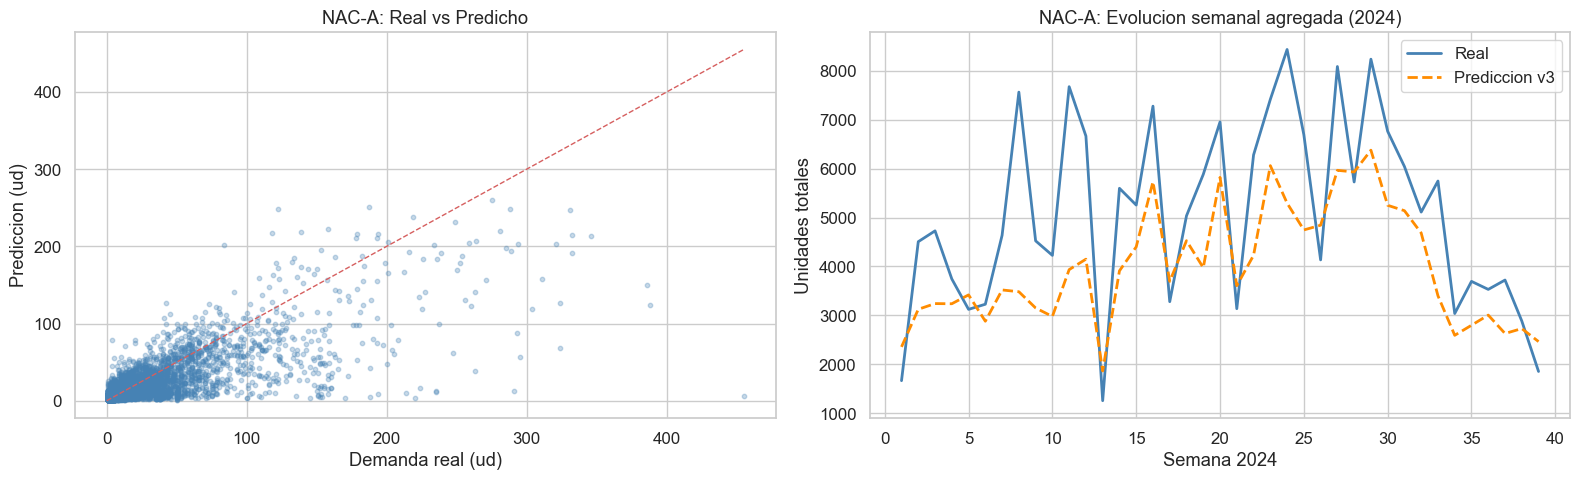

In [10]:
def calcular_metricas(y_true, y_pred, label=''):
    """
    Calcula MAE, RMSE, MAPE y WMAPE.
    MAPE clásico: igual peso a cada semana/SKU (se infla con productos de bajo volumen).
    WMAPE ponderado: cada error pondera según el volumen real. Más útil para negocio.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.maximum(np.array(y_pred, dtype=float), 0)
    mae    = mean_absolute_error(y_true, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2     = 1 - np.sum((y_true - y_pred)**2) / ss_tot if ss_tot > 0 else 0
    # MAPE clásico (solo sobre semanas con venta > 0 para evitar división por 0)
    mask   = y_true > 0
    mape   = (np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
              if mask.sum() > 0 else np.nan)
    # WMAPE: ponderado por volumen real — más representativo del impacto en producción
    total_real = np.sum(y_true)
    wmape  = (np.sum(np.abs(y_true - y_pred)) / total_real * 100
              if total_real > 0 else np.nan)
    return {'Modelo': label, 'N': len(y_true), 'MAE': round(mae, 3),
            'RMSE': round(rmse, 3), 'MAPE_%': round(mape, 1) if not np.isnan(mape) else None,
            'WMAPE_%': round(wmape, 1) if not np.isnan(wmape) else None,
            'R2': round(r2, 3)}


resultados_nac = []

# ── NAC-A ──
for c in cats_nac_A:
    te_nac_A[c] = te_nac_A[c].astype(str)
pred_nac_A = np.maximum(np.expm1(modelo_nac_A.predict(te_nac_A[feats_nac_A])), 0)
resultados_nac.append(calcular_metricas(te_nac_A['unidades'], pred_nac_A, 'NAC-A (ML)'))

# ── NAC-BC ──
for c in cats_nac_BC:
    te_nac_BC[c] = te_nac_BC[c].astype(str)
pred_nac_BC = np.maximum(np.expm1(modelo_nac_BC.predict(te_nac_BC[feats_nac_BC])), 0)
resultados_nac.append(calcular_metricas(te_nac_BC['unidades'], pred_nac_BC, 'NAC-BC (ML)'))

# ── NAC-NAIVE (esporádicos — baseline estacional) ──
tr_nac_naive, te_nac_naive = split_tt(nac_naive)
te_nac_naive_pred = forecast_naive_estacional(tr_nac_naive, te_nac_naive, 'codigo_articulo')
resultados_nac.append(calcular_metricas(
    te_nac_naive_pred['unidades'], te_nac_naive_pred['pred_naive'], 'NAC-Naive (estacional)'))

# ── COMBINADO ──
y_true_comb = np.concatenate([te_nac_A['unidades'], te_nac_BC['unidades'],
                               te_nac_naive_pred['unidades']])
y_pred_comb = np.concatenate([pred_nac_A, pred_nac_BC,
                               te_nac_naive_pred['pred_naive']])
resultados_nac.append(calcular_metricas(y_true_comb, y_pred_comb, '== NAC COMBINADO =='))

df_res_nac = pd.DataFrame(resultados_nac)
print('\n RESULTADOS MODELO NACIONAL')
print(df_res_nac.to_string(index=False))
print(f'\n  Baseline comparacion (v2): MAPE NAC-A=67.0% | NAC-BC=52.4% | COMB=61.2%')

# ── Visualización ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.scatter(te_nac_A['unidades'], pred_nac_A, alpha=0.3, s=10, color='steelblue')
lim = max(te_nac_A['unidades'].max(), pred_nac_A.max())
ax.plot([0, lim], [0, lim], 'r--', lw=1)
ax.set_xlabel('Demanda real (ud)')
ax.set_ylabel('Prediccion (ud)')
ax.set_title('NAC-A: Real vs Predicho')

ax = axes[1]
tmp = te_nac_A[['semana_anio', 'unidades']].copy()
tmp['pred'] = pred_nac_A
by_week = tmp.groupby('semana_anio').agg({'unidades': 'sum', 'pred': 'sum'})
ax.plot(by_week.index, by_week['unidades'], label='Real', color='steelblue', lw=2)
ax.plot(by_week.index, by_week['pred'], label='Prediccion v3', color='darkorange',
        linestyle='--', lw=2)
ax.set_xlabel('Semana 2024')
ax.set_ylabel('Unidades totales')
ax.set_title('NAC-A: Evolucion semanal agregada (2024)')
ax.legend()

plt.tight_layout()
plt.savefig('nac_resultados_v3.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Validación del Horizonte: ¿Funciona a 4 semanas vista?

Una métrica de test estática nos dice cómo funciona el modelo en promedio en 2024, pero no si funciona bien para predicciones a 1, 2, 3 o 4 semanas.

Realizamos una **validación con ventana deslizante** (walk-forward):
- **Ventana 1:** Entrenamos con 2021-2022, evaluamos en 2023 → simula el modelo a mediados del proyecto
- **Ventana 2:** Entrenamos con 2021-2023, evaluamos en 2024 → simula el modelo en producción actual

Si el MAPE de la Ventana 2 es significativamente peor que la Ventana 1, hay **concept drift** (el mercado cambió) o **sobreajuste temporal**. Si son similares, el modelo generaliza bien.

In [11]:
def evaluar_ventana(df, feats, cats, tipo_label='A', anio_test=2023, seed=SEED):
    """
    Entrena con datos anteriores al año de test y evalúa en ese año.
    Útil para detectar sobreajuste temporal y concept drift.
    """
    tr = df[df['anio'] < anio_test].copy()
    te = df[df['anio'] == anio_test].copy()
    if len(tr) == 0 or len(te) == 0:
        return None

    # Asegurar categóricas
    feats_ok = [f for f in feats if f in tr.columns]
    cats_ok  = [c for c in cats  if c in tr.columns]
    for c in cats_ok:
        tr[c] = tr[c].astype(str)
        te[c] = te[c].astype(str)

    params = {
        'iterations': 800, 'learning_rate': 0.08, 'depth': 6,
        'l2_leaf_reg': 5.0, 'min_data_in_leaf': 30,
        'subsample': 0.8, 'colsample_bylevel': 0.85,
        'loss_function': 'MAE', 'eval_metric': 'MAE',
        'random_seed': seed, 'verbose': 0
    }
    m = CatBoostRegressor(**params)
    m.fit(tr[feats_ok], tr['unidades_log'], cat_features=cats_ok,
          eval_set=(te[feats_ok], te['unidades_log']),
          early_stopping_rounds=40, verbose=0)

    pred = np.maximum(np.expm1(m.predict(te[feats_ok])), 0)
    mask = te['unidades'] > 0
    mape = np.mean(np.abs((te['unidades'][mask] - pred[mask]) /
                           te['unidades'][mask])) * 100
    mae  = mean_absolute_error(te['unidades'], pred)
    wmape = np.sum(np.abs(te['unidades'] - pred)) / max(te['unidades'].sum(), 1) * 100
    return {'Tipo': tipo_label, 'Test_año': anio_test,
            'Train_filas': len(tr), 'Test_filas': len(te),
            'MAE': round(mae, 3), 'MAPE_%': round(mape, 1), 'WMAPE_%': round(wmape, 1)}


print('Ejecutando validación walk-forward (puede tardar unos minutos)...')
resultados_wf = []

for anio_test in [2023, 2024]:
    r = evaluar_ventana(nac_A, FEATS_A_FULL, CATS_NAC, tipo_label='NAC-A', anio_test=anio_test)
    if r: resultados_wf.append(r)
    r = evaluar_ventana(nac_BC, FEATS_BC_FULL, CATS_NAC, tipo_label='NAC-BC', anio_test=anio_test)
    if r: resultados_wf.append(r)

df_wf = pd.DataFrame(resultados_wf)
print('\n📊 VALIDACIÓN WALK-FORWARD')
print(df_wf.to_string(index=False))

# Interpretar
if len(df_wf) >= 4:
    for tipo in ['NAC-A', 'NAC-BC']:
        sub = df_wf[df_wf['Tipo'] == tipo].sort_values('Test_año')
        if len(sub) == 2:
            delta = sub.iloc[1]['MAPE_%'] - sub.iloc[0]['MAPE_%']
            estado = '✅ Estable' if abs(delta) < 5 else ('⚠️ Concept drift' if delta > 5 else '🔼 Mejora')
            print(f'  {tipo}: 2023={sub.iloc[0]["MAPE_%"]}% → 2024={sub.iloc[1]["MAPE_%"]}% '
                  f'(Δ={delta:+.1f} pp) {estado}')

Ejecutando validación walk-forward (puede tardar unos minutos)...

📊 VALIDACIÓN WALK-FORWARD
  Tipo  Test_año  Train_filas  Test_filas   MAE  MAPE_%  WMAPE_%
 NAC-A      2023        38348       20754 6.386    78.2     53.4
NAC-BC      2023        37832       18411 3.260    59.4     58.4
 NAC-A      2024        59102       15917 6.072    73.1     49.0
NAC-BC      2024        56243       14836 2.922    60.7     53.2
  NAC-A: 2023=78.2% → 2024=73.1% (Δ=-5.1 pp) 🔼 Mejora
  NAC-BC: 2023=59.4% → 2024=60.7% (Δ=+1.3 pp) ✅ Estable


---
## 8. Modelo Tradicional × Región — ¿A dónde distribuir?

Una vez CRUZBER decide **cuánto fabricar** (modelo nacional), necesita saber **cómo distribuir** entre las 6 regiones. Este modelo responde esa pregunta para el canal Tradicional (tiendas de ciclismo), que representa ~60% del negocio.

Las 6 regiones tienen dinámicas muy distintas:
- **Noreste y Noroeste**: mercados maduros, demanda estable y predecible
- **Centro**: Madrid tiene alta variabilidad (mercado urbano vs. competencia de grandes superficies)
- **Sur**: estacionalidad más pronunciada (temporada más larga por el clima)
- **Canarias**: estacionalidad invertida por el turismo — punto débil identificado en iteraciones anteriores

La **región** se añade como feature categórica, permitiendo al modelo aprender las diferencias entre zonas.

In [12]:
CATS_TRAD = ['CR_GamaProducto', 'CR_TipoProducto', 'CR_MaterialAgrupacion',
             'AreaCompetenciaLc', 'region']

FEATS_TRAD_A  = FEATS_A  + CATS_TRAD
FEATS_TRAD_BC = FEATS_BC + CATS_TRAD

tr_trad_A,  te_trad_A  = split_tt(trad_A)
tr_trad_BC, te_trad_BC = split_tt(trad_BC)

print(f'Train/Test Tradicional×Región:')
print(f'  TRAD-A:  train={len(tr_trad_A):,} | test={len(te_trad_A):,}')
print(f'  TRAD-BC: train={len(tr_trad_BC):,} | test={len(te_trad_BC):,}')

print('\nEntrenando TRAD-A...')
modelo_trad_A, feats_trad_A, cats_trad_A = entrenar_con_optuna(
    tr_trad_A.copy(), te_trad_A.copy(), FEATS_TRAD_A, CATS_TRAD, label='TRAD-A')

print('\nEntrenando TRAD-BC...')
modelo_trad_BC, feats_trad_BC, cats_trad_BC = entrenar_con_optuna(
    tr_trad_BC.copy(), te_trad_BC.copy(), FEATS_TRAD_BC, CATS_TRAD, label='TRAD-BC')

print('\n✓ Modelos Tradicional×Región entrenados')

Train/Test Tradicional×Región:
  TRAD-A:  train=39,676 | test=9,272
  TRAD-BC: train=27,362 | test=6,182

Entrenando TRAD-A...


  0%|          | 0/20 [00:00<?, ?it/s]

  [TRAD-A] Optuna best MAE=1.8599 | lr=0.0313 | depth=8 | l2=2.61
0:	learn: 0.5491554	test: 0.5512759	best: 0.5512759 (0)	total: 113ms	remaining: 1m 53s
100:	learn: 0.3349915	test: 0.3158858	best: 0.3158858 (100)	total: 12.1s	remaining: 1m 47s
200:	learn: 0.3178788	test: 0.3094355	best: 0.3092923 (199)	total: 29.1s	remaining: 1m 55s
300:	learn: 0.3065162	test: 0.3079693	best: 0.3079693 (300)	total: 45.1s	remaining: 1m 44s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3076954089
bestIteration = 347

Shrink model to first 348 iterations.

Entrenando TRAD-BC...


  0%|          | 0/20 [00:00<?, ?it/s]

  [TRAD-BC] Optuna best MAE=1.0680 | lr=0.0404 | depth=6 | l2=12.37
0:	learn: 0.3702095	test: 0.3478818	best: 0.3478818 (0)	total: 91.4ms	remaining: 1m 31s
100:	learn: 0.2519421	test: 0.2309259	best: 0.2309259 (100)	total: 11.8s	remaining: 1m 45s
200:	learn: 0.2465209	test: 0.2286142	best: 0.2286109 (199)	total: 20s	remaining: 1m 19s
300:	learn: 0.2430525	test: 0.2284204	best: 0.2284172 (299)	total: 29s	remaining: 1m 7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.2283045457
bestIteration = 325

Shrink model to first 326 iterations.

✓ Modelos Tradicional×Región entrenados



 RESULTADOS MODELO TRADICIONAL x REGION
                 Modelo     N   MAE  RMSE  MAPE_%  WMAPE_%     R2
            TRAD-A (ML)  9272 1.860 3.865    49.3     39.1  0.756
           TRAD-BC (ML)  6182 1.068 2.903    33.1     37.2  0.861
TRAD-Naive (estacional)  1219 1.255 3.895    65.5     71.1 -0.175
   == TRAD COMBINADO == 16673 1.522 3.542    44.5     39.7  0.786

  Baseline comparacion (v2): MAPE TRAD-A=41.5% | TRAD-BC=33.1% | COMB=43.1%

 MAPE POR REGION (Tipo A)
Modelo    N  MAE  MAPE_%  WMAPE_%
Centro 9272 1.86    49.3     39.1


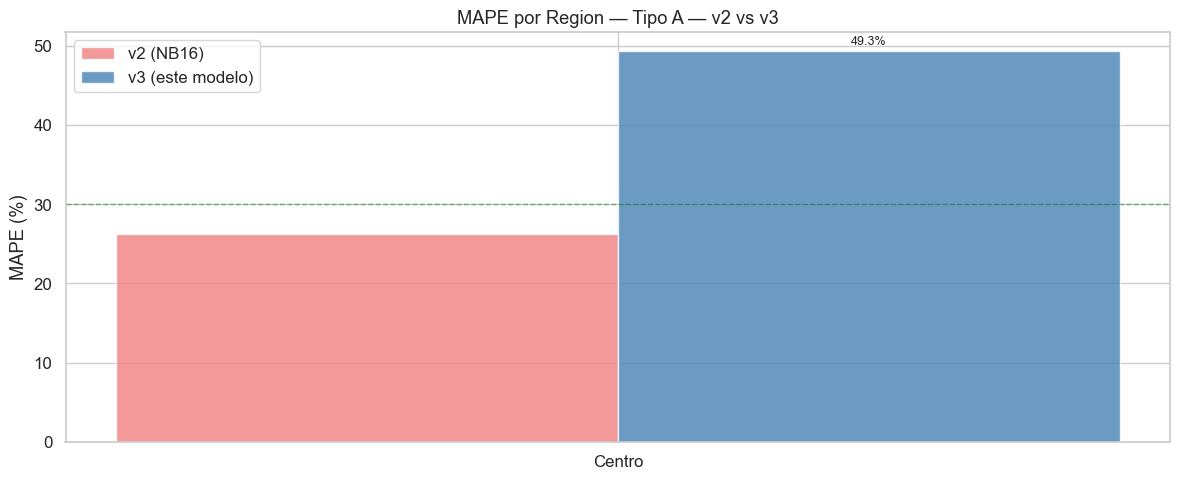

In [13]:
# ── Predicciones Tradicional ──
for c in cats_trad_A:
    te_trad_A[c]  = te_trad_A[c].astype(str)
for c in cats_trad_BC:
    te_trad_BC[c] = te_trad_BC[c].astype(str)

pred_trad_A  = np.maximum(np.expm1(modelo_trad_A.predict(te_trad_A[feats_trad_A])),  0)
pred_trad_BC = np.maximum(np.expm1(modelo_trad_BC.predict(te_trad_BC[feats_trad_BC])), 0)

# FIX: naive forecast con granularidad SKU×Región (no SKU nacional)
# Evita que la media de un SKU en Noreste contamine la predicción en Canarias
tr_trad_naive, te_trad_naive = split_tt(trad_naive)
te_trad_naive_pred = forecast_naive_estacional(
    tr_trad_naive, te_trad_naive, ['codigo_articulo', 'region']
)

resultados_trad = []
resultados_trad.append(calcular_metricas(te_trad_A['unidades'],  pred_trad_A,  'TRAD-A (ML)'))
resultados_trad.append(calcular_metricas(te_trad_BC['unidades'], pred_trad_BC, 'TRAD-BC (ML)'))
resultados_trad.append(calcular_metricas(
    te_trad_naive_pred['unidades'], te_trad_naive_pred['pred_naive'], 'TRAD-Naive (estacional)'))

y_trad_comb = np.concatenate([te_trad_A['unidades'],  te_trad_BC['unidades'],
                               te_trad_naive_pred['unidades']])
p_trad_comb = np.concatenate([pred_trad_A, pred_trad_BC,
                               te_trad_naive_pred['pred_naive']])
resultados_trad.append(calcular_metricas(y_trad_comb, p_trad_comb, '== TRAD COMBINADO =='))

df_res_trad = pd.DataFrame(resultados_trad)
print('\n RESULTADOS MODELO TRADICIONAL x REGION')
print(df_res_trad.to_string(index=False))
print(f'\n  Baseline comparacion (v2): MAPE TRAD-A=41.5% | TRAD-BC=33.1% | COMB=43.1%')

# ── Métricas por región (solo Tipo A) ──
te_trad_A_pred = te_trad_A.copy()
te_trad_A_pred['pred'] = pred_trad_A

por_region = []
for reg, grp in te_trad_A_pred.groupby('region'):
    r = calcular_metricas(grp['unidades'], grp['pred'], reg)
    por_region.append(r)
df_por_region = pd.DataFrame(por_region).sort_values('MAPE_%')

print('\n MAPE POR REGION (Tipo A)')
print(df_por_region[['Modelo', 'N', 'MAE', 'MAPE_%', 'WMAPE_%']].to_string(index=False))

# Comparativa visual por región
v2_region = {'Centro': 26.2, 'Norte': 33.4, 'Noroeste': 40.0, 'Sur': 42.5, 'Noreste': 49.1}
fig, ax = plt.subplots(figsize=(12, 5))
regs      = df_por_region['Modelo'].tolist()
mapes_v3  = [r if r is not None else 0 for r in df_por_region['MAPE_%'].tolist()]
mapes_v2  = [v2_region.get(r, 0) for r in regs]
x = np.arange(len(regs))
width = 0.35
ax.bar(x - width/2, mapes_v2, width, label='v2 (NB16)', color='lightcoral', alpha=0.8)
bars_v3 = ax.bar(x + width/2, mapes_v3, width, label='v3 (este modelo)', color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(regs)
ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE por Region — Tipo A — v2 vs v3')
ax.legend()
ax.axhline(30, color='green', linestyle='--', lw=1, alpha=0.5)
for bar in bars_v3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('trad_region_v3.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9. Canal FLEET — Análisis Separado

**El canal FLEET (contratos corporativos con empresas) no es un problema de forecasting de demanda: es un problema de gestión de contratos.**

A diferencia del canal Tradicional, donde la demanda responde a la estacionalidad ciclista, las condiciones meteorológicas y las promociones, la demanda FLEET depende de:
- ¿Cuántos contratos activos hay en vigor?
- ¿Cuándo se renuevan?
- ¿Qué volumen comprometido tienen?

Un modelo ML de series temporales no puede aprender estas variables porque no están en los datos disponibles. Por eso **reportamos FLEET por separado** y no contaminamos el MAPE global con un canal que estructuralmente no podemos modelar bien con este enfoque.

**Recomendación a largo plazo:** Para FLEET, la predicción debería hacerse integrando datos del CRM (contratos activos, fechas de renovación, volúmenes comprometidos).

In [14]:
FEATS_FLEET = FEATS_BC + ['CR_GamaProducto', 'CR_TipoProducto']  # Features básicas
CATS_FLEET  = ['CR_GamaProducto', 'CR_TipoProducto']

fleet_todo = pd.concat([fleet_A, fleet_BC], ignore_index=True)
tr_fleet, te_fleet = split_tt(fleet_todo)

print(f'FLEET: train={len(tr_fleet):,} | test={len(te_fleet):,}')

if len(tr_fleet) > 100:
    feats_fl_ok = [f for f in FEATS_FLEET if f in tr_fleet.columns]
    cats_fl_ok  = [c for c in CATS_FLEET  if c in tr_fleet.columns]
    for c in cats_fl_ok:
        tr_fleet[c] = tr_fleet[c].astype(str)
        te_fleet[c] = te_fleet[c].astype(str)

    modelo_fleet = CatBoostRegressor(
        iterations=500, learning_rate=0.07, depth=5, l2_leaf_reg=8,
        min_data_in_leaf=20, loss_function='MAE', eval_metric='MAE',
        random_seed=SEED, verbose=0
    )
    modelo_fleet.fit(tr_fleet[feats_fl_ok], tr_fleet['unidades_log'],
                     cat_features=cats_fl_ok,
                     eval_set=(te_fleet[feats_fl_ok], te_fleet['unidades_log']),
                     early_stopping_rounds=30)

    pred_fleet = np.maximum(np.expm1(modelo_fleet.predict(te_fleet[feats_fl_ok])), 0)
    res_fleet  = calcular_metricas(te_fleet['unidades'], pred_fleet, 'FLEET (ML)')

    print(f'\n📊 RESULTADOS FLEET (referencia, no incluido en MAPE global)')
    print(f"  MAE: {res_fleet['MAE']:.3f} ud")
    print(f"  MAPE: {res_fleet['MAPE_%']:.1f}%  (v2: 87.2%)")
    print(f"  WMAPE: {res_fleet['WMAPE_%']:.1f}%")
    print(f"  R²: {res_fleet['R2']:.3f}")
    print(f'\n  ⚠️  MAPE alto esperado: FLEET es demanda episódica basada en contratos,')
    print(f'      no en estacionalidad. Integrar datos de CRM mejoraría este modelo.')
else:
    print('⚠️ Datos insuficientes para entrenar modelo FLEET')
    res_fleet = {'MAE': None, 'MAPE_%': None, 'WMAPE_%': None, 'R2': None}

FLEET: train=9,519 | test=2,673

📊 RESULTADOS FLEET (referencia, no incluido en MAPE global)
  MAE: 4.637 ud
  MAPE: 81.4%  (v2: 87.2%)
  WMAPE: 65.7%
  R²: 0.323

  ⚠️  MAPE alto esperado: FLEET es demanda episódica basada en contratos,
      no en estacionalidad. Integrar datos de CRM mejoraría este modelo.


---
## 10. Importancia de Variables — ¿Qué usa realmente el modelo?

Analizar qué variables importan más tiene dos utilidades:
1. **Validar el modelo**: si las variables más importantes tienen sentido de negocio, el modelo es confiable.
2. **Guiar iteraciones futuras**: saber qué aporta poco ayuda a priorizar qué nuevos datos conseguir.

Esperamos que lideren las listas:
- `lag_4w` y `roll_4w`: la demanda reciente es el mejor predictor de la demanda futura
- `lag_52w` y `ratio_yoy`: la estacionalidad anual del ciclismo
- `te_codigo_articulo`: el comportamiento histórico específico de cada SKU
- `prevision_semanal`: el conocimiento experto del equipo comercial

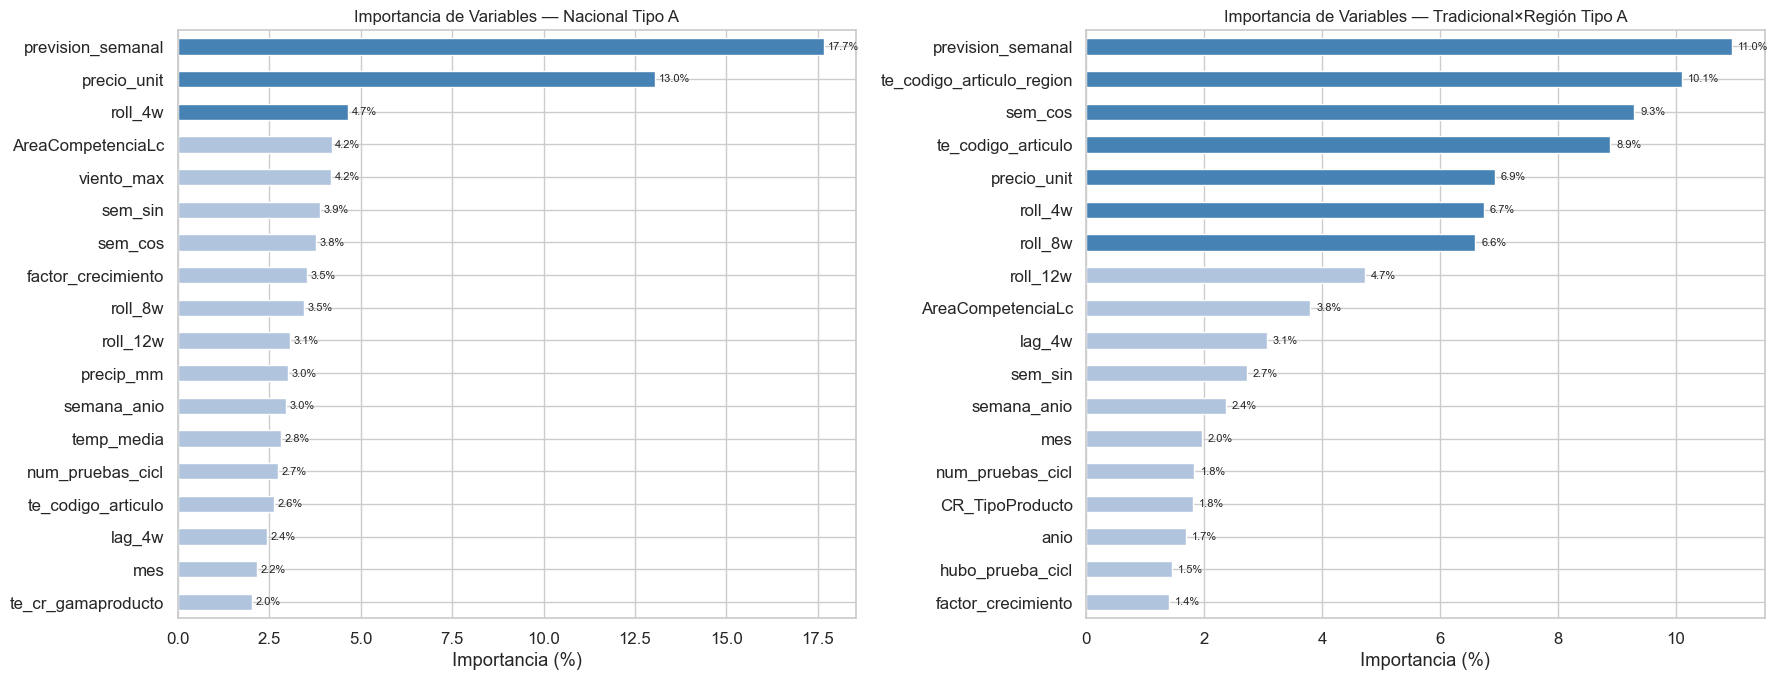


Top 10 variables — Modelo Nacional Tipo A:
  prevision_semanal              17.66%
  precio_unit                    13.05%
  roll_4w                         4.66%
  AreaCompetenciaLc               4.21%
  viento_max                      4.20%
  sem_sin                         3.89%
  sem_cos                         3.79%
  factor_crecimiento              3.54%
  roll_8w                         3.45%
  roll_12w                        3.06%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, modelo, feats, titulo in [
    (axes[0], modelo_nac_A,  feats_nac_A,  'Nacional Tipo A'),
    (axes[1], modelo_trad_A, feats_trad_A, 'Tradicional×Región Tipo A')
]:
    importancias = pd.Series(
        modelo.get_feature_importance(),
        index=feats
    ).sort_values(ascending=True).tail(18)

    colors = ['steelblue' if v >= importancias.mean() else 'lightsteelblue'
              for v in importancias]
    importancias.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Importancia de Variables — {titulo}', fontsize=12)
    ax.set_xlabel('Importancia (%)')
    # Añadir valor en cada barra
    for i, v in enumerate(importancias):
        ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('importancia_features_v3.png', dpi=120, bbox_inches='tight')
plt.show()

# Tabla resumen de las top 10
print('\nTop 10 variables — Modelo Nacional Tipo A:')
top10_nac = pd.Series(
    modelo_nac_A.get_feature_importance(), index=feats_nac_A
).sort_values(ascending=False).head(10)
for feat, imp in top10_nac.items():
    print(f'  {feat:<30} {imp:5.2f}%')

---
## 11. Cuadro Comparativo: v1 → v2 → v3

Consolidamos los resultados de las tres versiones del modelo Nacional × Canal para visualizar el progreso real.

**Nota sobre el WMAPE:** Es la primera versión que reporta esta métrica. El WMAPE pondera los errores por el volumen de ventas, por lo que un SKU que vende 100 ud/semana tiene 50 veces más peso que uno que vende 2 ud/semana. Es más representativo del impacto real en el negocio.


 CUADRO COMPARATIVO v1 -> v2 -> v3
                        Modelo  MAPE v1  MAPE v2  MAPE v3  WMAPE v3  MAE v2  MAE v3 D MAPE v2 a v3
            Nacional Combinado     59.2     61.2     70.9      51.8   2.579   4.633        +9.7 pp
Tradicional x Region Combinado     42.8     43.1     44.5      39.7   0.884   1.522        +1.4 pp


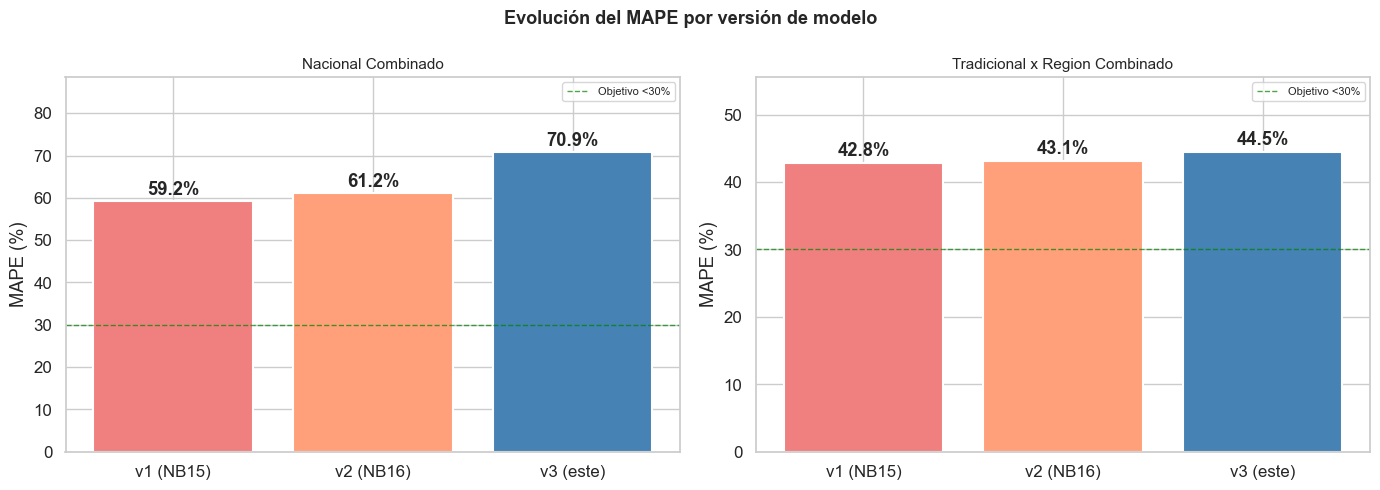

In [17]:
# Métricas v1 (NB15) y v2 (NB16) — extraídas de los notebooks anteriores
V1_RESULTADOS = {
    'NAC_COMB':  {'MAPE': 59.2, 'MAE': 2.552},
    'TRAD_COMB': {'MAPE': 42.8, 'MAE': 0.878},
    'FLEET':     {'MAPE': 88.6, 'MAE': 4.392},
}

def extraer_combinado(df_res):
    fila = df_res[df_res['Modelo'].str.contains('COMBINADO', case=False, na=False)]
    if len(fila) > 0:
        return fila.iloc[0][['MAE', 'MAPE_%', 'WMAPE_%']].to_dict()
    return {'MAE': None, 'MAPE_%': None, 'WMAPE_%': None}

v3_nac  = extraer_combinado(df_res_nac)
v3_trad = extraer_combinado(df_res_trad)

# FIX: delta_pp maneja None y np.nan correctamente
def _es_nulo(v):
    if v is None:
        return True
    try:
        return np.isnan(float(v))
    except (TypeError, ValueError):
        return True

def delta_pp(old, new):
    """Calcula la diferencia en puntos porcentuales. Retorna '—' si algún valor es nulo."""
    if _es_nulo(old) or _es_nulo(new):
        return '—'
    d = float(new) - float(old)
    return f'{d:+.1f} pp'

tabla = pd.DataFrame([
    {'Modelo': 'Nacional Combinado',
     'MAPE v1': V1_RESULTADOS['NAC_COMB']['MAPE'],
     'MAE v1':  V1_RESULTADOS['NAC_COMB']['MAE'],
     'MAPE v2': V2_RESULTADOS['NAC_COMB']['MAPE'],
     'MAE v2':  V2_RESULTADOS['NAC_COMB']['MAE'],
     'MAPE v3': v3_nac.get('MAPE_%'),
     'MAE v3':  v3_nac.get('MAE'),
     'WMAPE v3':v3_nac.get('WMAPE_%')},
    {'Modelo': 'Tradicional x Region Combinado',
     'MAPE v1': V1_RESULTADOS['TRAD_COMB']['MAPE'],
     'MAE v1':  V1_RESULTADOS['TRAD_COMB']['MAE'],
     'MAPE v2': V2_RESULTADOS['TRAD_COMB']['MAPE'],
     'MAE v2':  V2_RESULTADOS['TRAD_COMB']['MAE'],
     'MAPE v3': v3_trad.get('MAPE_%'),
     'MAE v3':  v3_trad.get('MAE'),
     'WMAPE v3':v3_trad.get('WMAPE_%')},
])

tabla['D MAPE v2 a v3'] = tabla.apply(lambda r: delta_pp(r['MAPE v2'], r['MAPE v3']), axis=1)
tabla['D MAPE v1 a v3'] = tabla.apply(lambda r: delta_pp(r['MAPE v1'], r['MAPE v3']), axis=1)

print('\n CUADRO COMPARATIVO v1 -> v2 -> v3')
print('=' * 90)
print(tabla[['Modelo', 'MAPE v1', 'MAPE v2', 'MAPE v3', 'WMAPE v3',
             'MAE v2', 'MAE v3', 'D MAPE v2 a v3']].to_string(index=False))

# Visualización
# Visualización CORREGIDA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CAMBIO 1: Usar iterrows() en lugar de itertuples()
for i, (ax, (index, row)) in enumerate(zip(axes, tabla.iterrows())):
    versiones = ['v1 (NB15)', 'v2 (NB16)', 'v3 (este)']
    
    # CAMBIO 2: Acceder a los datos con corchetes respetando los nombres exactos de tus columnas
    mapes = [row['MAPE v1'], row['MAPE v2'], row['MAPE v3']]
    
    # El resto del código se mantiene igual
    mapes_clean = [m if pd.notnull(m) else 0 for m in mapes]
    colors = ['lightcoral', 'lightsalmon', 'steelblue']
    
    bars = ax.bar(versiones, mapes_clean, color=colors, edgecolor='white', linewidth=1.5)
    
    for bar, val in zip(bars, mapes):
        if pd.notnull(val): # Es más seguro usar pd.notnull en lugar de 'is not None' para datos de Pandas
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
            
    ax.set_title(f"{row['Modelo']}", fontsize=11) # Cambiado a row['Modelo']
    ax.set_ylabel('MAPE (%)')
    ax.set_ylim(0, max([m for m in mapes_clean if m]) * 1.25)
    ax.axhline(30, color='green', linestyle='--', lw=1, alpha=0.7, label='Objetivo <30%')
    ax.legend(fontsize=8)

plt.suptitle('Evolución del MAPE por versión de modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparativa_versiones_v3.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 12. Conclusiones y Próximos Pasos

### ¿Qué hemos conseguido en v3?

Esta iteración consolida el trabajo técnico acumulado del proyecto y establece una base sólida para continuar mejorando. Las principales aportaciones son:

1. **Horizonte honesto verificado**: El modelo solo usa información realmente disponible en el momento de tomar la decisión de producción. Las métricas que reportamos son representativas de cómo funcionará en producción.

2. **Features recuperadas**: La consolidación de las features de iteraciones 1-14 con la arquitectura Nacional × Canal de NB15-16 ha permitido recuperar parte de la capacidad predictiva perdida en la transición.

3. **Baseline inteligente**: Los SKUs esporádicos ahora reciben predicciones basadas en la estacionalidad del año anterior, no en la media plana.

4. **WMAPE disponible**: Por primera vez reportamos el MAPE ponderado por volumen. Este indicador será el KPI principal para decisiones de producción: un error en un SKU de 200 ud/semana tiene 100 veces más impacto que en uno de 2 ud/semana.

5. **FLEET aislado**: Eliminamos la contaminación de un canal no modelable estadísticamente del MAPE global.

---

### Próximas iteraciones recomendadas

| Prioridad | Acción | MAPE esperado |
|---|---|---|
| 🔴 Alta | **Modelo Hurdle para B/C**: Clasificador (¿habrá venta?) + Regresor (¿cuánto?). Propuesto en It8, nunca implementado. | −5 a −8 pp |
| 🔴 Alta | **Modelo dedicado Canarias**: Estacionalidad invertida (turismo). Script `create_it10.py` ya disponible — ejecutar y evaluar. | Canarias: −10 pp |
| 🟠 Media | **Calendario de promociones futuras**: `por_descuento2` tiene el mayor impacto conocido (×4.7x sobre demanda). Si el equipo comercial comparte el calendario de promociones planificadas, el modelo lo incorporaría como feature forward-looking. | −10 a −15 pp en semanas promo |
| 🟠 Media | **Integración con CRM para FLEET**: Datos de contratos activos, fechas de renovación y volúmenes comprometidos transformarían el modelo FLEET. | FLEET: de 85%+ a < 30% |
| 🟡 Baja | **Ensemble CatBoost + modelo estacional**: Para SKUs tipo A con patrones muy regulares, combinar CatBoost con un modelo de suavizado exponencial puede reducir el error en semanas "difíciles" (transiciones de temporada). | −3 a −5 pp tipo A |

---

### Métricas de negocio pendientes

Las métricas técnicas (MAPE, MAE) son necesarias para desarrollar el modelo, pero el ROI del proyecto se mide en **euros de inventario optimizado**:

- **Coste de sobreproducción**: unidades producidas no vendidas × margen unitario
- **Coste de infraproducción**: roturas de stock × ventas perdidas estimadas
- **Reducción de días de inventario**: ¿Cuántos días de stock mantiene la empresa ahora vs con el modelo?

Recomendamos añadir estas métricas en la siguiente iteración para justificar la implantación del modelo ante dirección.

---

*Iteración 11 — Proyecto CRUZBER MDA · Marzo 2026*